## Data Quality

https://www.youtube.com/watch?v=ZgTAuRoo2Rg

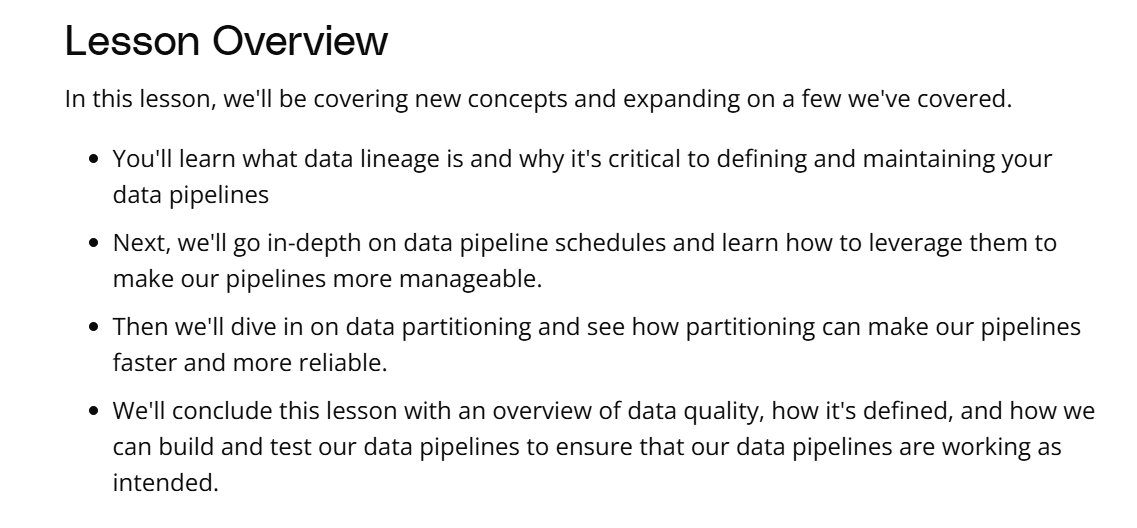

## What is Data Lineage?

https://www.youtube.com/watch?v=-mxEFaZ3pto

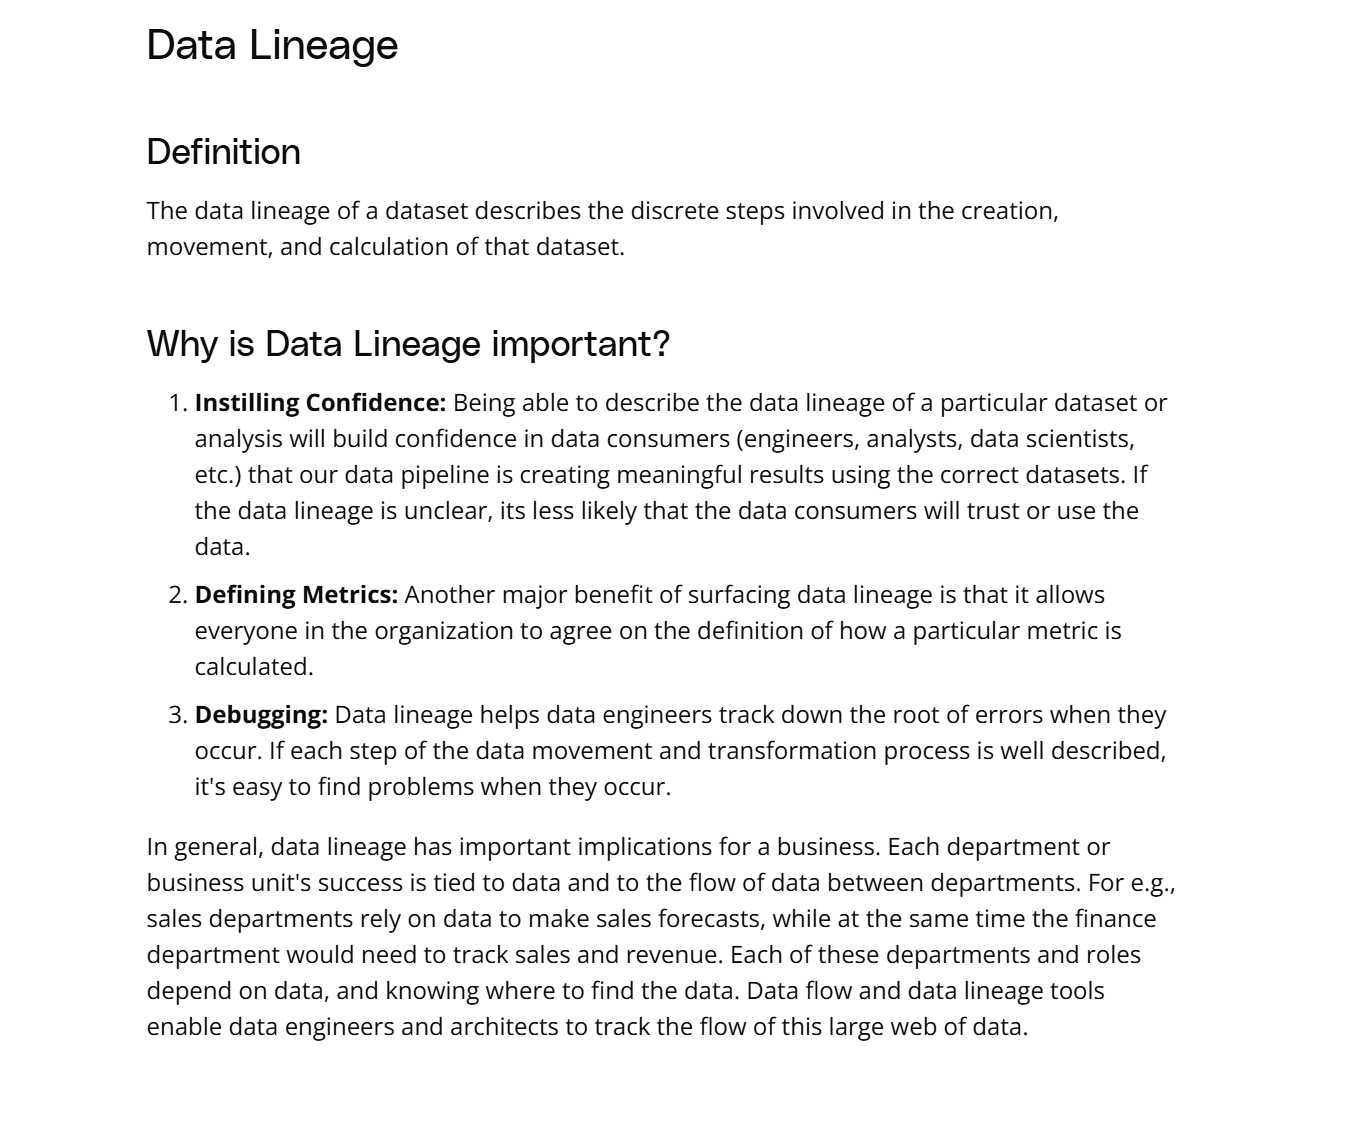

## Visualizing Data Lineage

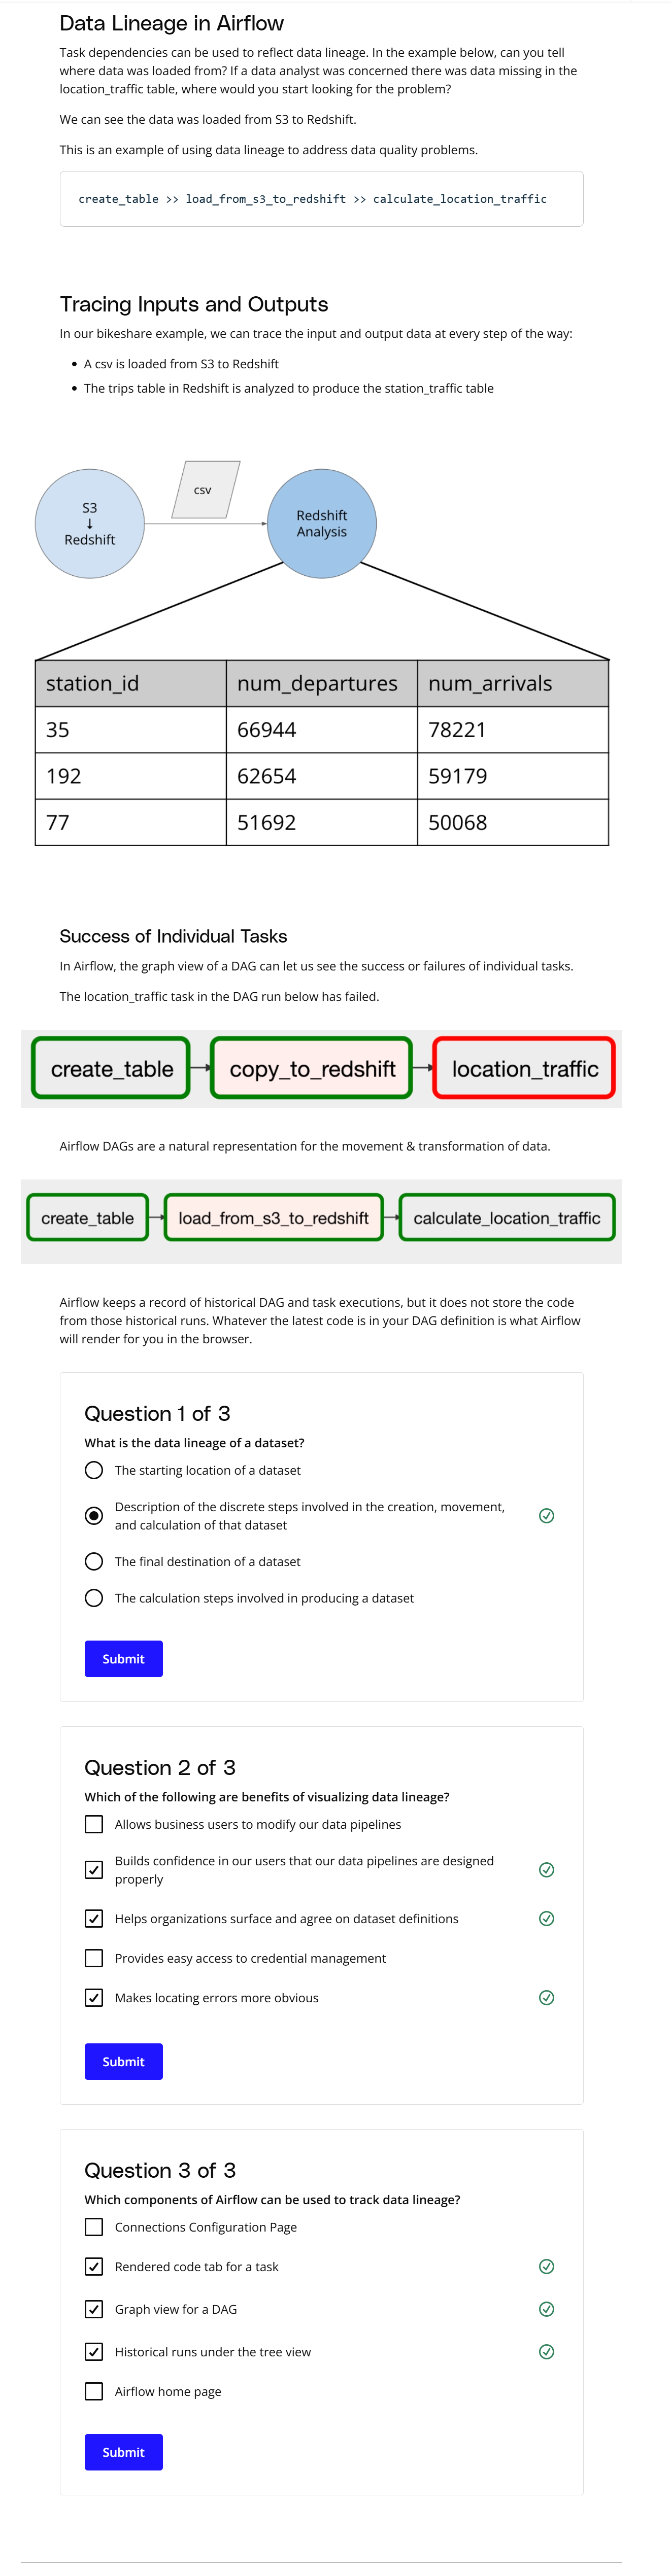

## Exercise 1: Data Lineage in Airflow

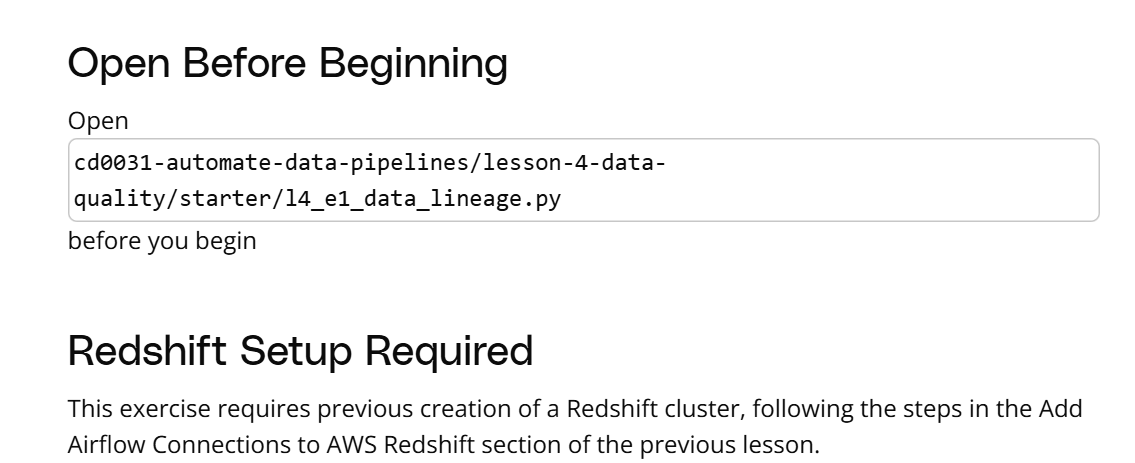

## Solution 1: Data Lineage in Airflow

https://www.youtube.com/watch?v=AdrZ6qFnL2E

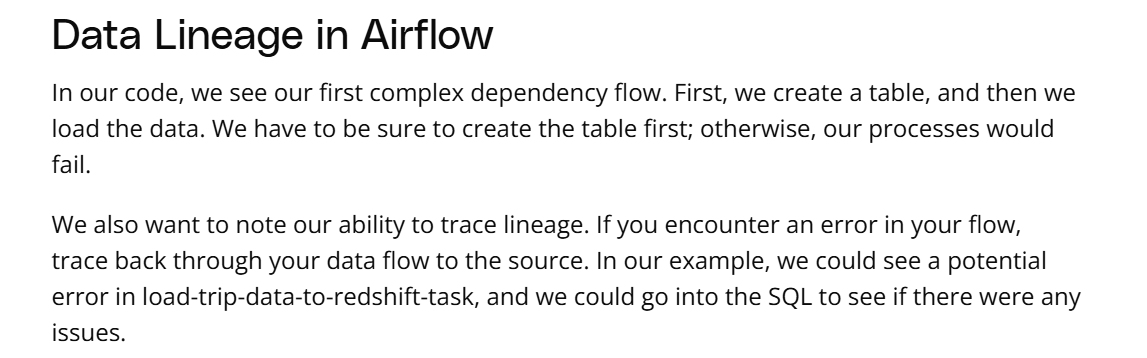

In [ ]:
import pendulum


from airflow.decorators import dag, task
from airflow.secrets.metastore import MetastoreBackend
from airflow.hooks.postgres_hook import PostgresHook
from airflow.operators.postgres_operator import PostgresOperator

from udacity.common import sql_statements

@dag(
    start_date=pendulum.now()
)
def data_lineage():


    @task()
    def load_trip_data_to_redshift():
        metastoreBackend = MetastoreBackend()
        aws_connection=metastoreBackend.get_connection("aws_credentials")
        redshift_hook = PostgresHook("redshift")
        sql_stmt = sql_statements.COPY_ALL_TRIPS_SQL.format(
            aws_connection.login,
            aws_connection.password,
        )
        redshift_hook.run(sql_stmt)

    load_trip_data_to_redshift_task= load_trip_data_to_redshift()

    @task()
    def load_station_data_to_redshift():
        metastoreBackend = MetastoreBackend()
        aws_connection=metastoreBackend.get_connection("aws_credentials")
        redshift_hook = PostgresHook("redshift")
        sql_stmt = sql_statements.COPY_STATIONS_SQL.format(
            aws_connection.login,
            aws_connection.password,
        )
        redshift_hook.run(sql_stmt)

    load_station_data_to_redshift_task = load_station_data_to_redshift()

    create_trips_table = PostgresOperator(
        task_id="create_trips_table",
        postgres_conn_id="redshift",
        sql=sql_statements.CREATE_TRIPS_TABLE_SQL
    )


    create_stations_table = PostgresOperator(
        task_id="create_stations_table",
        postgres_conn_id="redshift",
        sql=sql_statements.CREATE_STATIONS_TABLE_SQL,
    )


    calculate_traffic_task = PostgresOperator(
        task_id='calculate_location_traffic',
        postgres_conn_id="redshift",
        sql=sql_statements.LOCATION_TRAFFIC_SQL,
    )

    create_trips_table >> load_trip_data_to_redshift_task >> calculate_traffic_task
    create_stations_table >> load_station_data_to_redshift_task 
data_lineage_dag = data_lineage()

## Data Pipeline Schedules

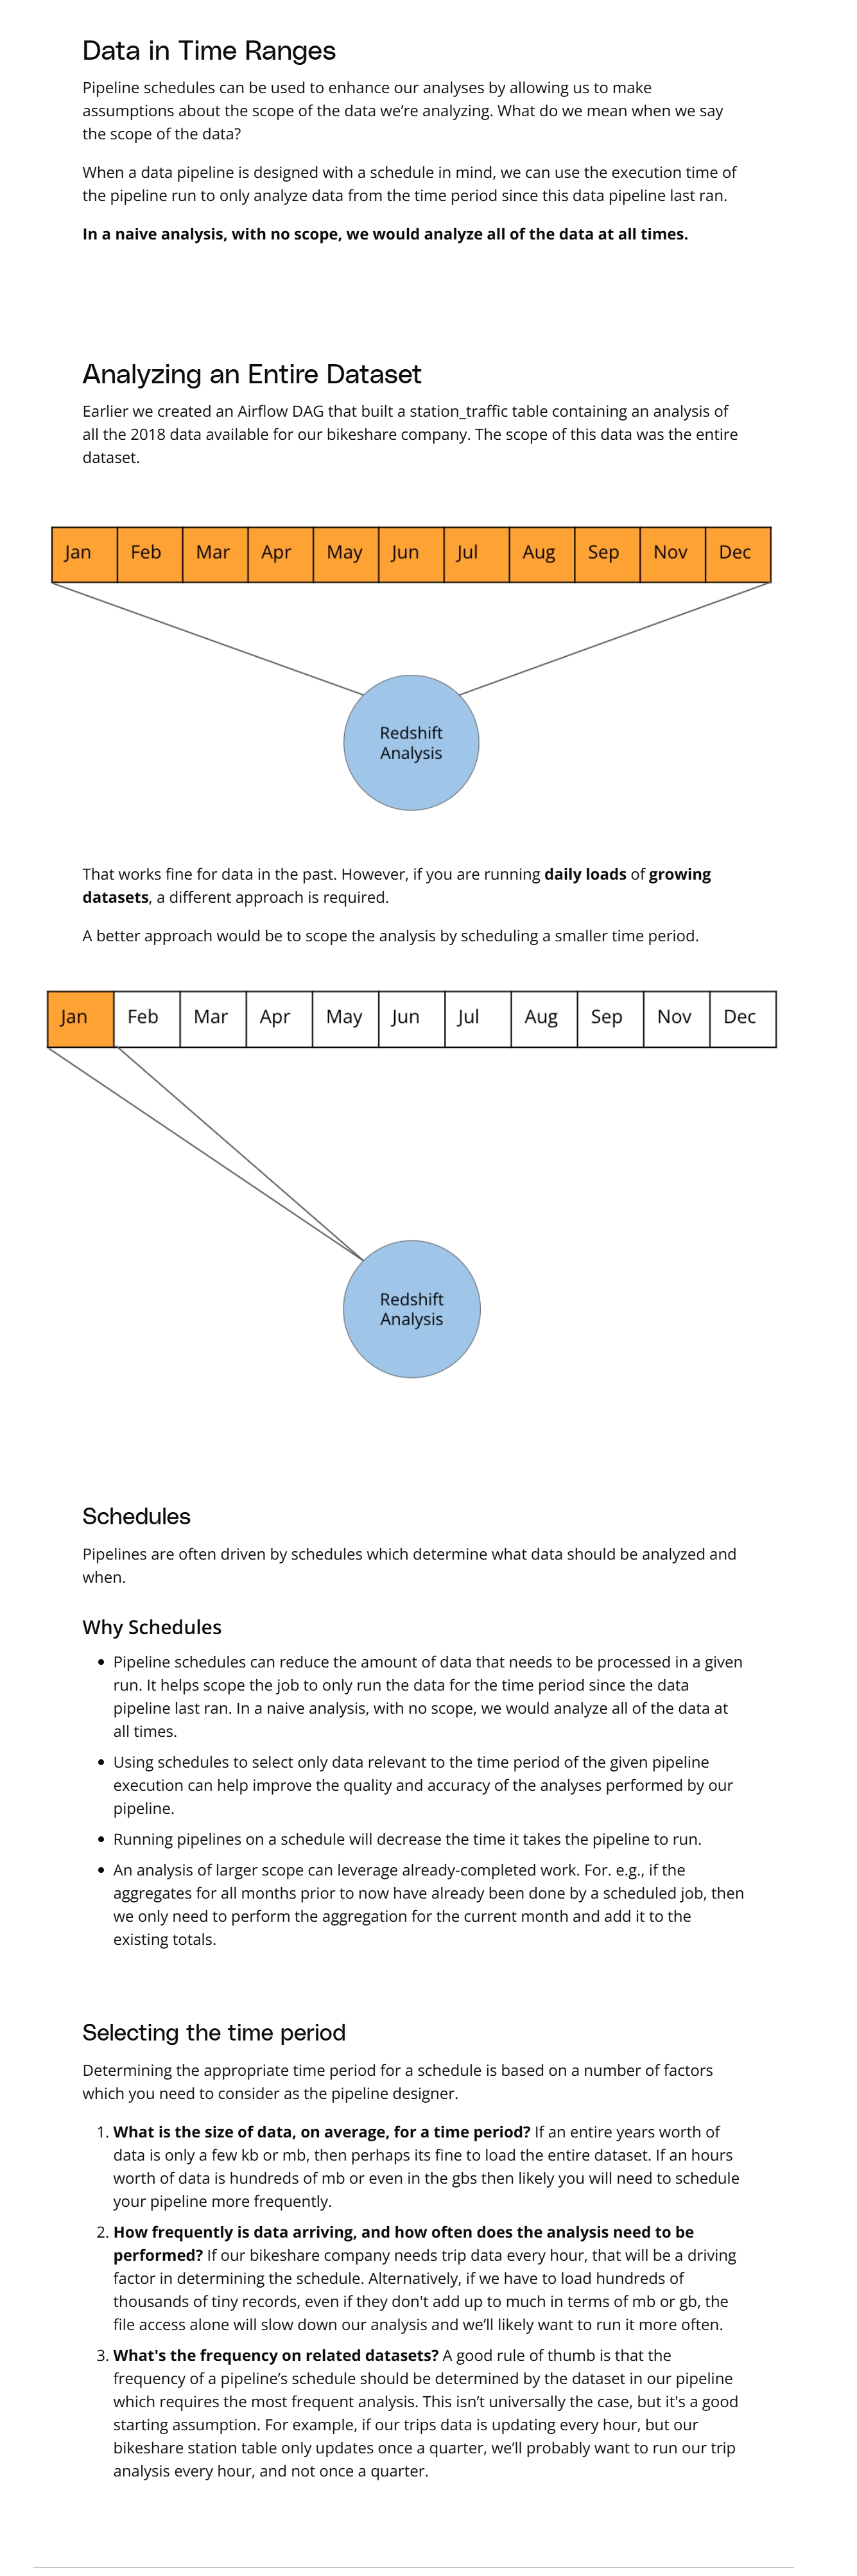

## Scheduling in Airflow

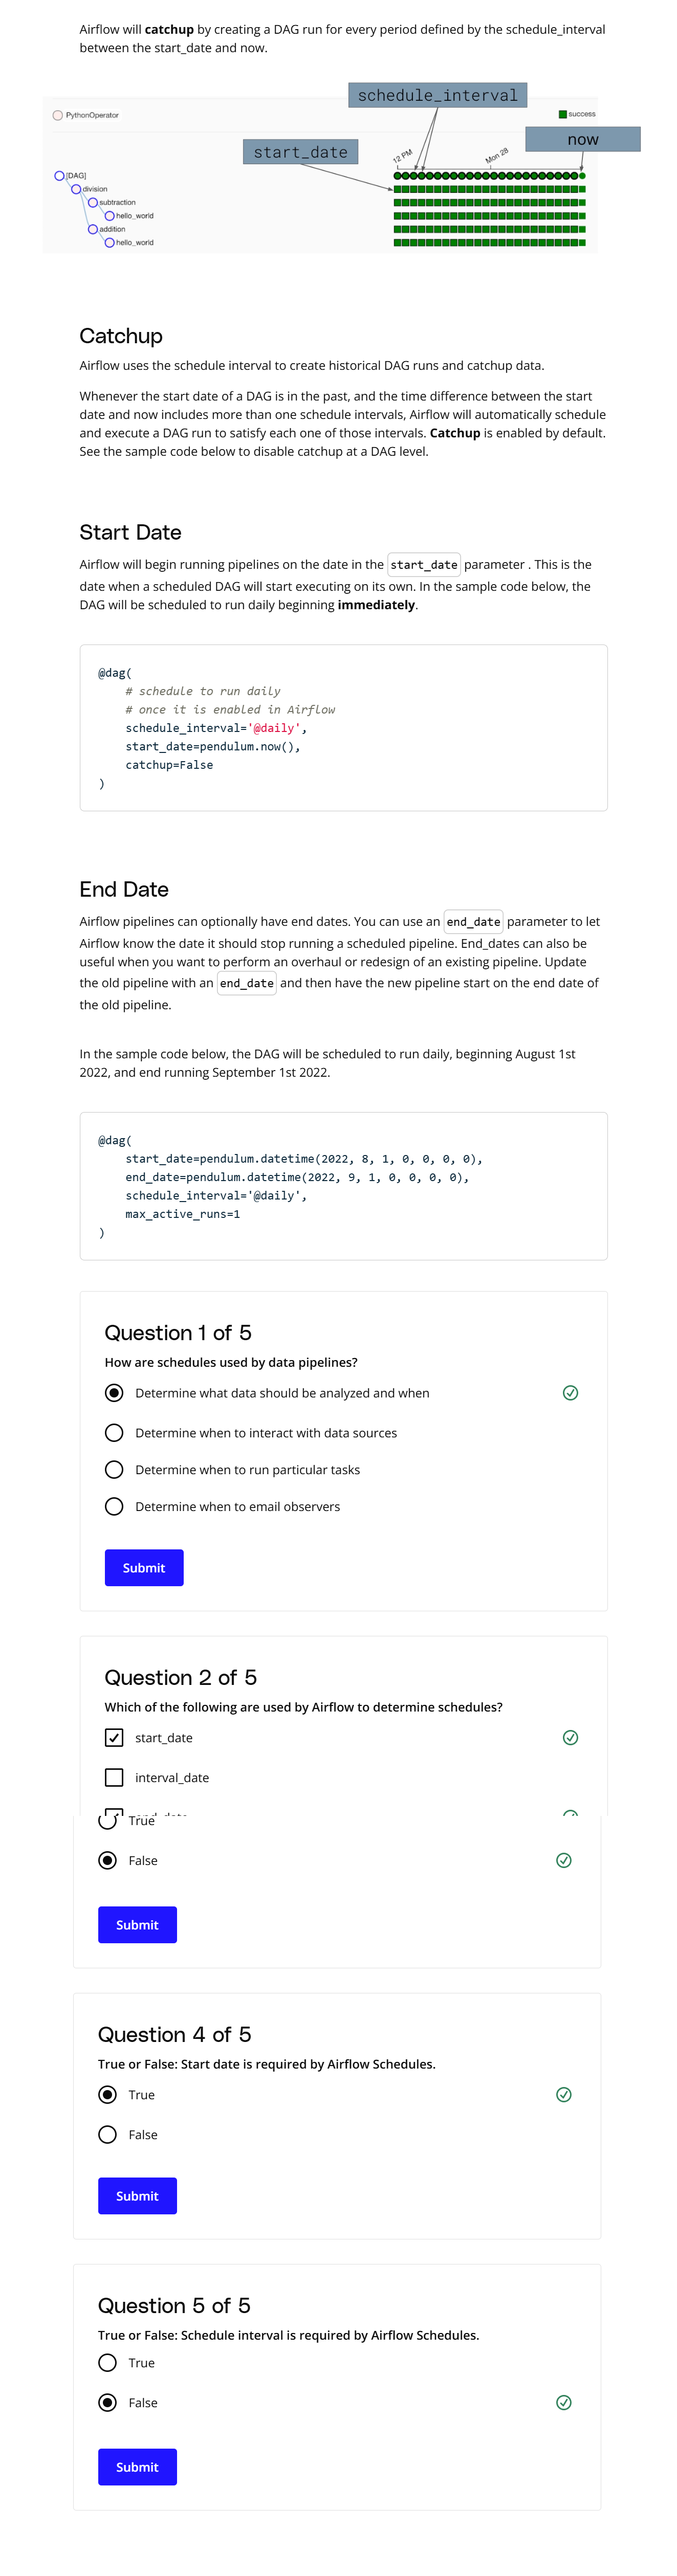

## Exercise 2: Schedules and Catchups in Airflow

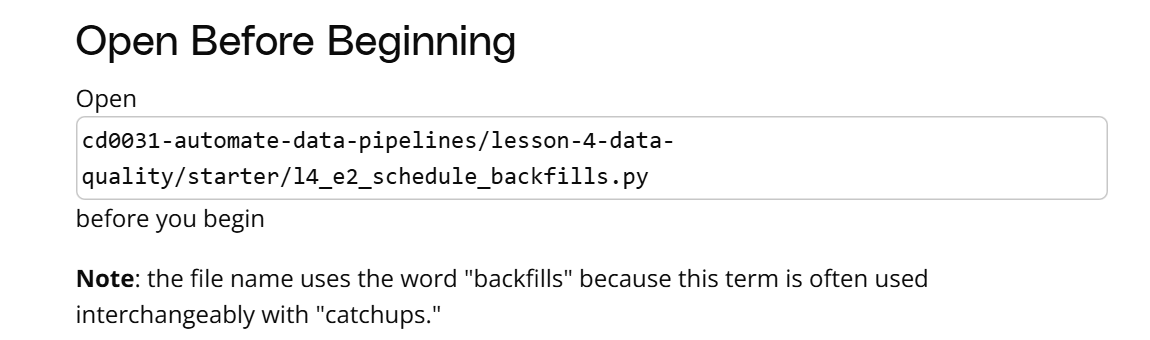

## Solution 2: Schedules and Catchups in Airflow

https://www.youtube.com/watch?v=CtBw1V7fImk

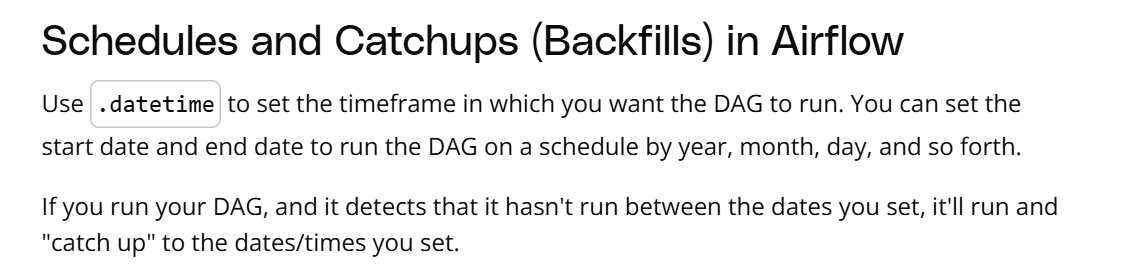

In [ ]:
import pendulum


from airflow.decorators import dag, task
from airflow.secrets.metastore import MetastoreBackend
from airflow.hooks.postgres_hook import PostgresHook
from airflow.operators.postgres_operator import PostgresOperator

from udacity.common import sql_statements

@dag(
    start_date=pendulum.datetime(2018, 1, 1, 0, 0, 0, 0),
    end_date=pendulum.datetime(2018, 2, 1, 0, 0, 0, 0),
    schedule_interval='@monthly',
    max_active_runs=1    
)
def schedule_backfills():


    @task()
    def load_trip_data_to_redshift():
        metastoreBackend = MetastoreBackend()
        aws_connection=metastoreBackend.get_connection("aws_credentials")
        redshift_hook = PostgresHook("redshift")
        sql_stmt = sql_statements.COPY_ALL_TRIPS_SQL.format(
            aws_connection.login,
            aws_connection.password,
        )
        redshift_hook.run(sql_stmt)

    load_trip_data_to_redshift_task= load_trip_data_to_redshift()

    @task()
    def load_station_data_to_redshift():
        metastoreBackend = MetastoreBackend()
        aws_connection=metastoreBackend.get_connection("aws_credentials")
        redshift_hook = PostgresHook("redshift")
        sql_stmt = sql_statements.COPY_STATIONS_SQL.format(
            aws_connection.login,
            aws_connection.password,
        )
        redshift_hook.run(sql_stmt)

    load_station_data_to_redshift_task = load_station_data_to_redshift()

    create_trips_table = PostgresOperator(
        task_id="create_trips_table",
        postgres_conn_id="redshift",
        sql=sql_statements.CREATE_TRIPS_TABLE_SQL
    )


    create_stations_table = PostgresOperator(
        task_id="create_stations_table",
        postgres_conn_id="redshift",
        sql=sql_statements.CREATE_STATIONS_TABLE_SQL,
    )

    create_trips_table >> load_trip_data_to_redshift_task
    create_stations_table >> load_station_data_to_redshift_task

schedule_backfills_dag = schedule_backfills()

## Data Partitioning

https://www.youtube.com/watch?v=DkA6f7v7vuY

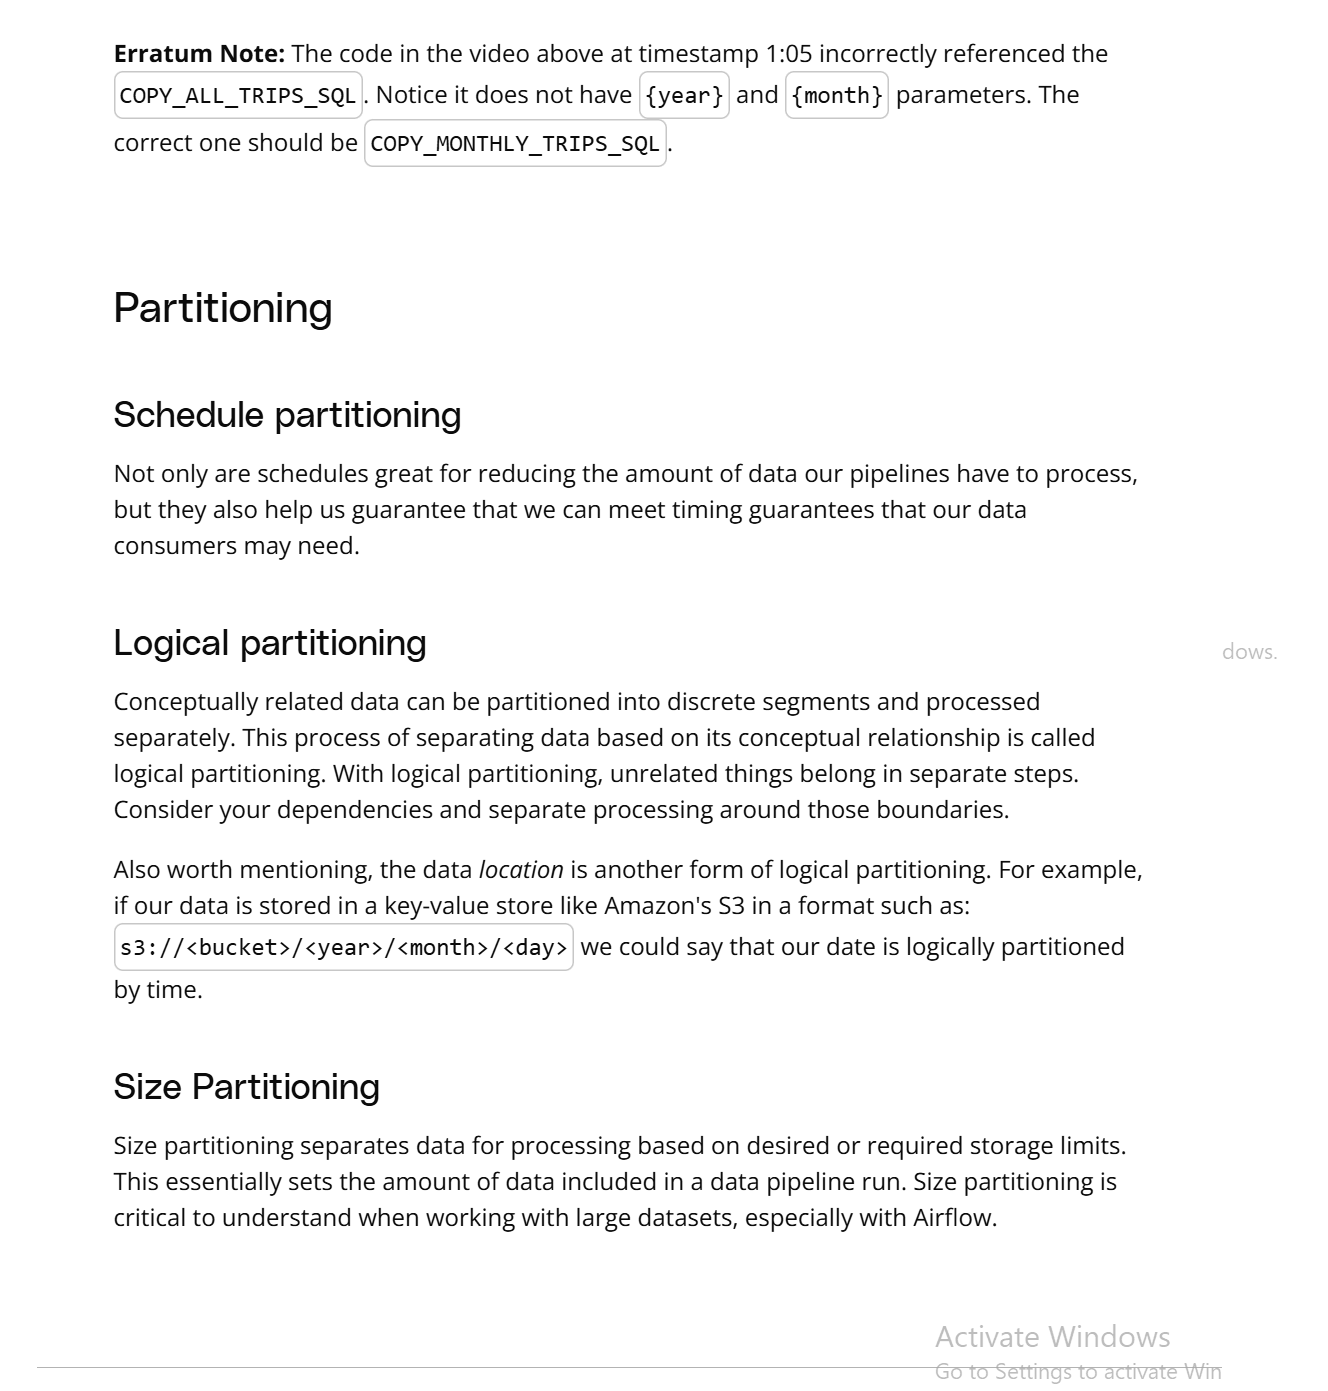

## Goals of Data Partitioning

https://www.youtube.com/watch?v=Ly3XBoVs1tU

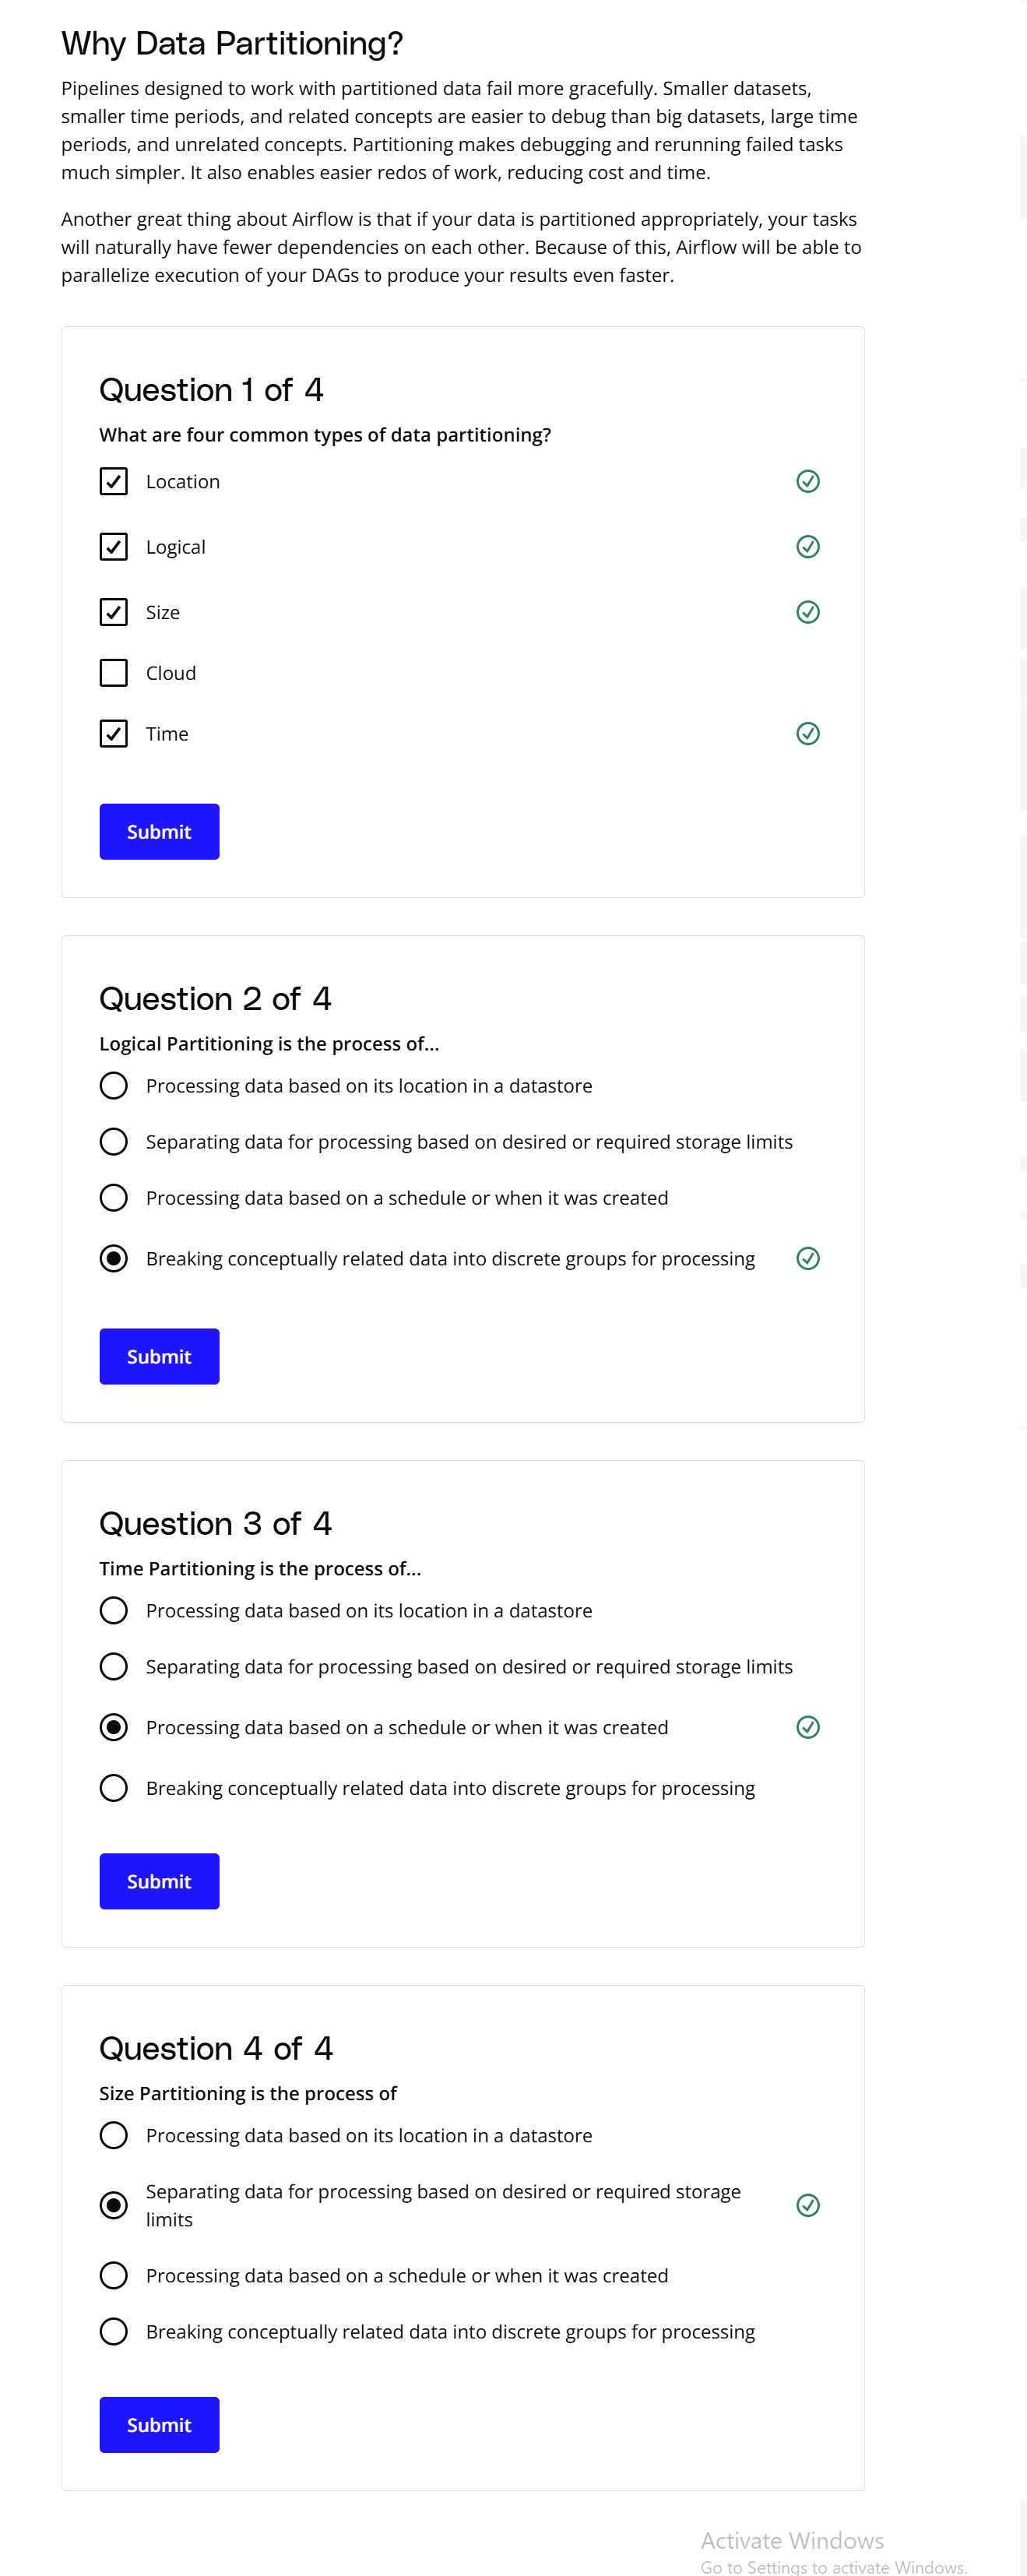

## Exercise 3: Data Partitioning

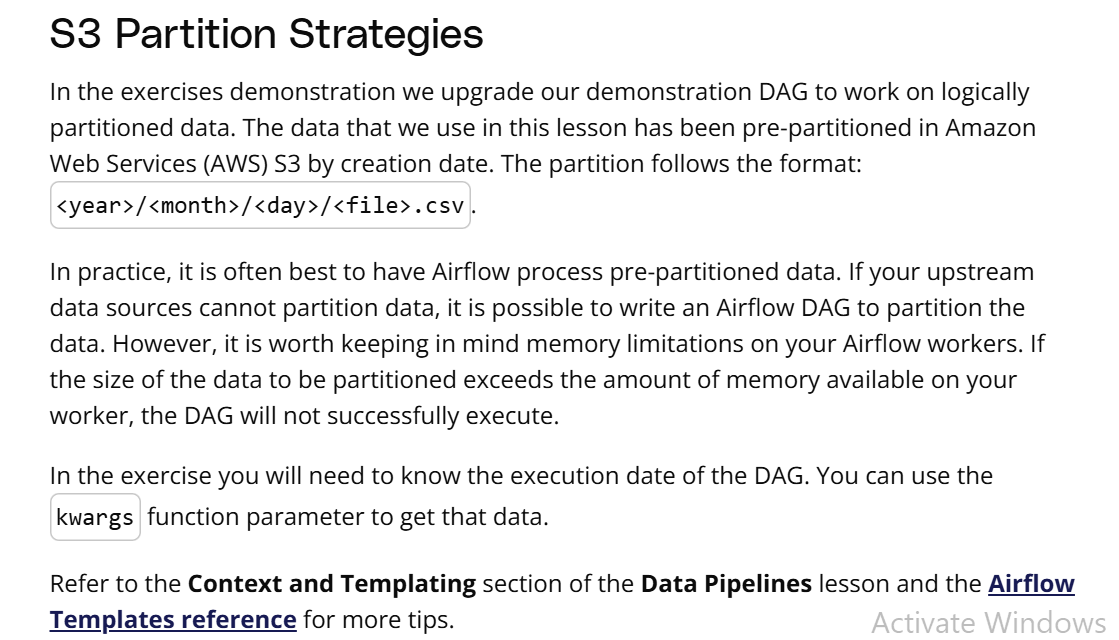

https://airflow.apache.org/docs/apache-airflow/stable/templates-ref.html

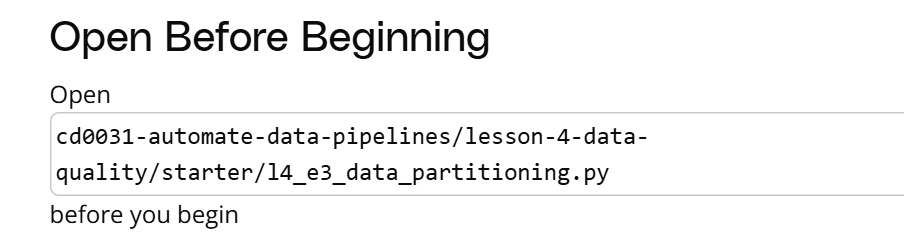

## Solution 3: Data Partitioning

https://www.youtube.com/watch?v=DkA6f7v7vuY

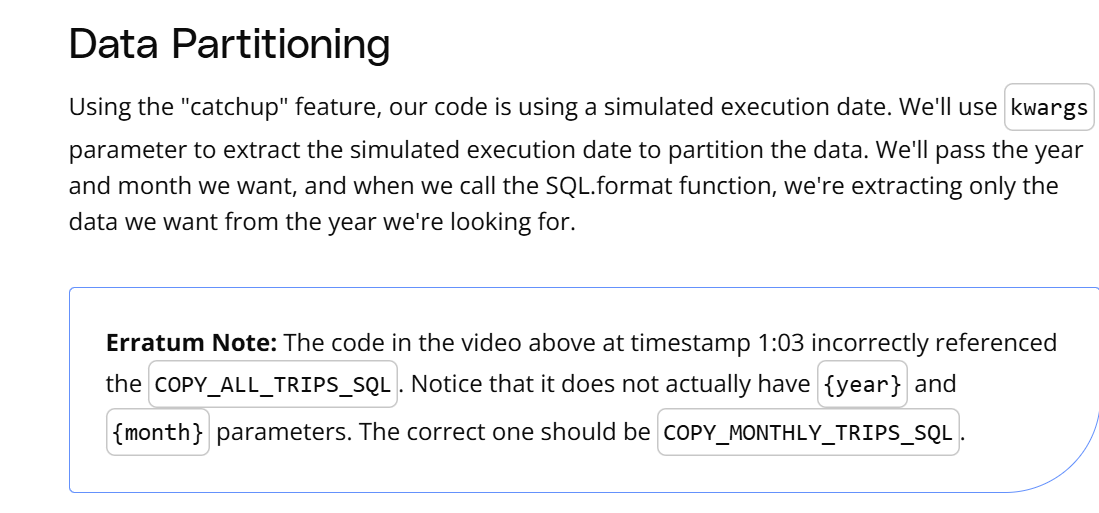

In [ ]:
import pendulum


from airflow.decorators import dag, task
from airflow.secrets.metastore import MetastoreBackend
from airflow.hooks.postgres_hook import PostgresHook
from airflow.operators.postgres_operator import PostgresOperator

from udacity.common import sql_statements

@dag(
    start_date=pendulum.datetime(2018, 1, 1, 0, 0, 0, 0),
    end_date=pendulum.datetime(2018, 2, 1, 0, 0, 0, 0),
    schedule_interval='@monthly',
    max_active_runs=1    
)
def data_partitioning():


    @task()
    def load_trip_data_to_redshift(*args,* *kwargs):
        metastoreBackend = MetastoreBackend()
        aws_connection=metastoreBackend.get_connection("aws_credentials")
        redshift_hook = PostgresHook("redshift")
        execution_date = kwargs["execution_date"]

        sql_stmt = sql_statements.COPY_MONTHLY_TRIPS_SQL.format(
            aws_connection.login,
            aws_connection.password,
            year=execution_date.year,
            month=execution_date.month
        )
        redshift_hook.run(sql_stmt)

    load_trip_data_to_redshift_task= load_trip_data_to_redshift()

    @task()
    def load_station_data_to_redshift():
        metastoreBackend = MetastoreBackend()
        aws_connection=metastoreBackend.get_connection("aws_credentials")
        redshift_hook = PostgresHook("redshift")
        sql_stmt = sql_statements.COPY_STATIONS_SQL.format(
            aws_connection.login,
            aws_connection.password,
        )
        redshift_hook.run(sql_stmt)

    load_station_data_to_redshift_task = load_station_data_to_redshift()

    create_trips_table = PostgresOperator(
        task_id="create_trips_table",
        postgres_conn_id="redshift",
        sql=sql_statements.CREATE_TRIPS_TABLE_SQL
    )


    create_stations_table = PostgresOperator(
        task_id="create_stations_table",
        postgres_conn_id="redshift",
        sql=sql_statements.CREATE_STATIONS_TABLE_SQL,
    )

    create_trips_table >> load_trip_data_to_redshift_task
    create_stations_table >> load_station_data_to_redshift_task

data_partitioning_dag = data_partitioning()

## Data Quality Requirements

https://www.youtube.com/watch?v=-ravmjI7RYk

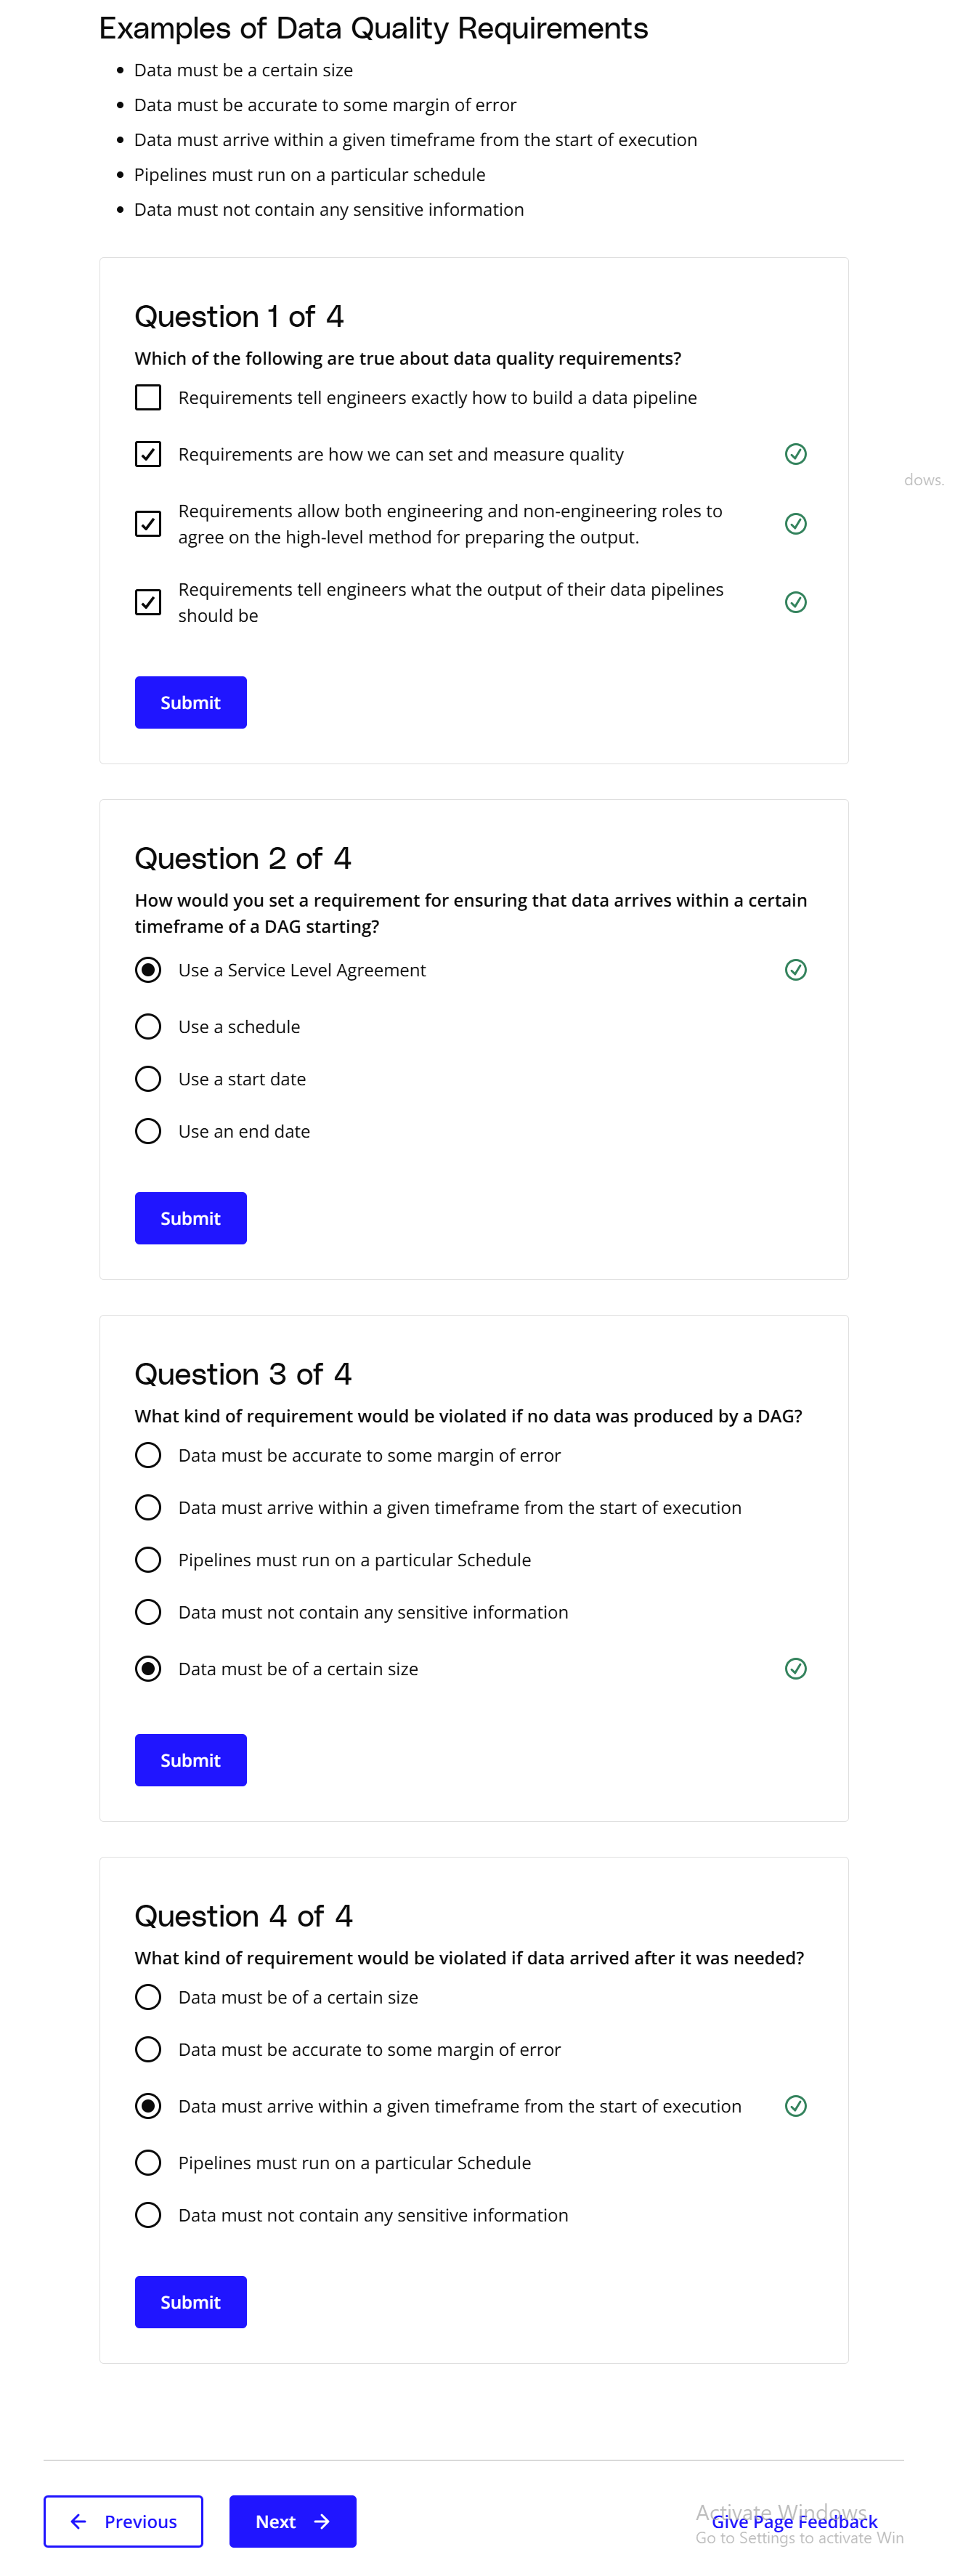

## Exercise 4: Data Quality

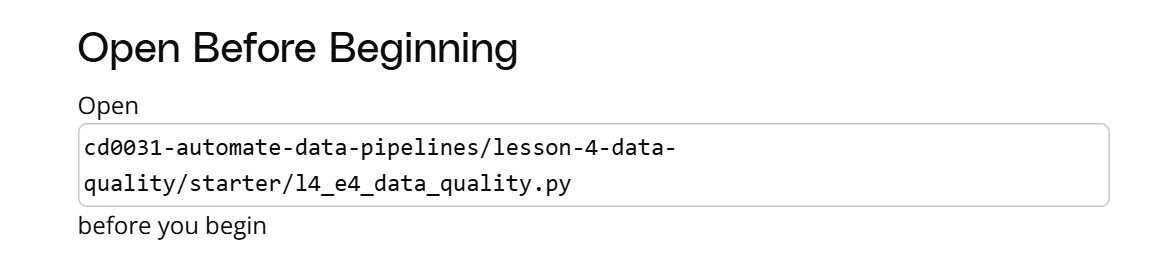

## Solution 4: Data Quality

https://www.youtube.com/watch?v=juhZAaNO2HY

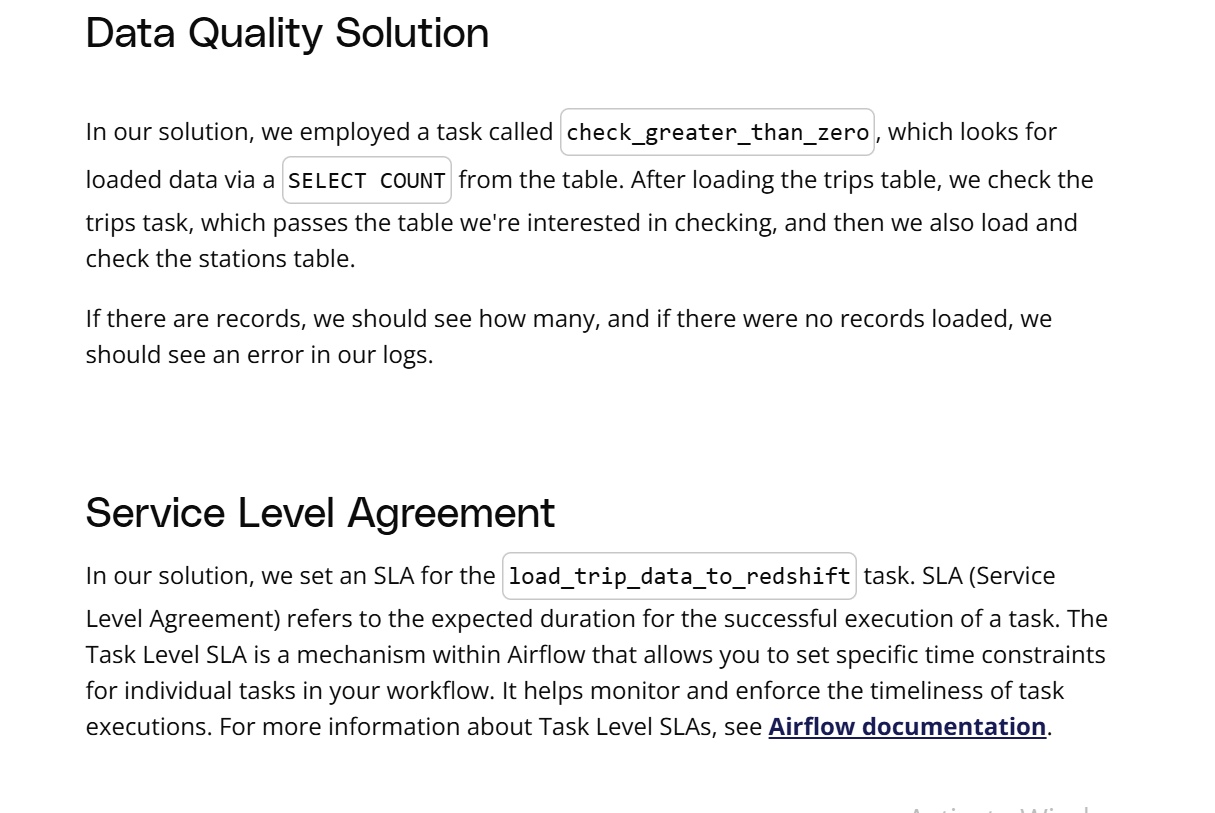

https://airflow.apache.org/docs/apache-airflow/stable/core-concepts/tasks.html#slas

In [ ]:
import pendulum
import datetime
import logging

from airflow.decorators import dag,task
from airflow.secrets.metastore import MetastoreBackend
from airflow.hooks.postgres_hook import PostgresHook
from airflow.operators.postgres_operator import PostgresOperator
from airflow.operators.python_operator import PythonOperator

from udacity.common import sql_statements

@dag(
    start_date=pendulum.now(),
    max_active_runs=1    
)
def data_quality():

    @task(sla=datetime.timedelta(hours=1))
    def load_trip_data_to_redshift(*args,* *kwargs):
        metastoreBackend = MetastoreBackend()
        aws_connection=metastoreBackend.get_connection("aws_credentials")
        redshift_hook = PostgresHook("redshift")
        sql_stmt = sql_statements.COPY_ALL_TRIPS_SQL.format(
            aws_connection.login,
            aws_connection.password
        )
        redshift_hook.run(sql_stmt)

    @task()
    def load_station_data_to_redshift(*args,* *kwargs):
        metastoreBackend = MetastoreBackend()
        aws_connection=metastoreBackend.get_connection("aws_credentials")
        redshift_hook = PostgresHook("redshift")
        sql_stmt = sql_statements.COPY_STATIONS_SQL.format(
            aws_connection.login,
            aws_connection.password,
        )
        redshift_hook.run(sql_stmt)

    @task()
    def check_greater_than_zero(*args,* *kwargs):
        table = kwargs["params"]["table"]
        redshift_hook = PostgresHook("redshift")
        records = redshift_hook.get_records(f"SELECT COUNT(*) FROM {table}")
        if len(records) < 1 or len(records[0]) < 1:
            raise ValueError(f"Data quality check failed. {table} returned no results")
        num_records = records[0][0]
        if num_records < 1:
            raise ValueError(f"Data quality check failed. {table} contained 0 rows")
        logging.info(f"Data quality on table {table} check passed with {records[0][0]} records")


    create_trips_table = PostgresOperator(
        task_id="create_trips_table",
        postgres_conn_id="redshift",
        sql=sql_statements.CREATE_TRIPS_TABLE_SQL
    )

    load_trips_task = load_trip_data_to_redshift()


    check_trips_task = check_greater_than_zero(
        params={
            'table':'trips'
        }
    )

    create_stations_table = PostgresOperator(
        task_id="create_stations_table",
        postgres_conn_id="redshift",
        sql=sql_statements.CREATE_STATIONS_TABLE_SQL,
    )

    load_stations_task = load_station_data_to_redshift()

    check_stations_task = check_greater_than_zero(
        params={
            'table': 'stations',
        }
    )


    create_trips_table >> load_trips_task
    create_stations_table >> load_stations_task
    load_stations_task >> check_stations_task
    load_trips_task >> check_trips_task

data_quality_dag = data_quality()

## Putting It All Together

https://www.youtube.com/watch?v=ogl8lzj4klA

Putting it All Together

Data Quality is incredibly important, and Airflow can help track the source of data by using data partitioning and catchups to compensate for sporadic data availability.

## Lesson Review

https://www.youtube.com/watch?v=oDQoL0Tntas

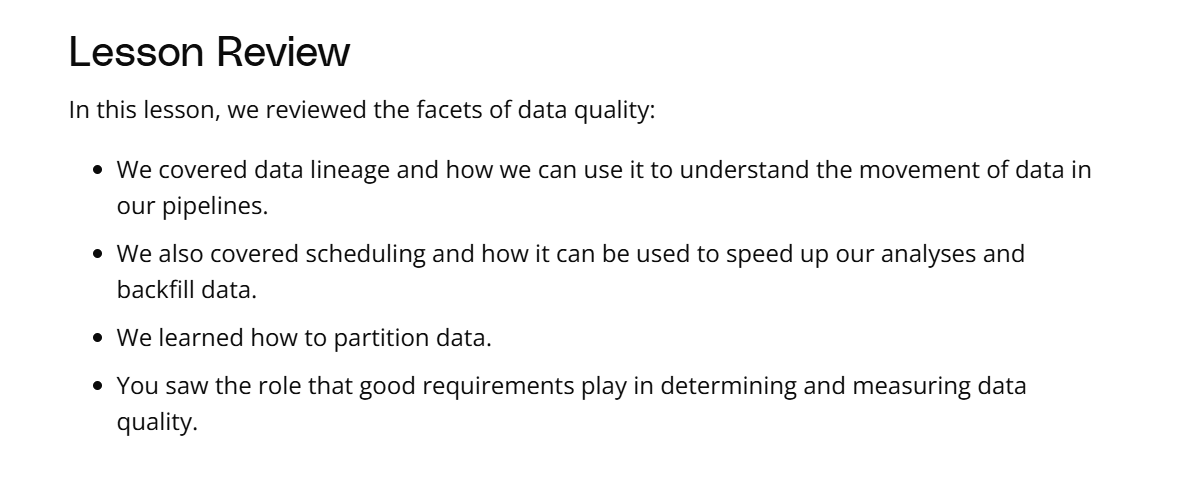